Connecting to NOAA climate server...
Extracting equatorial Pacific region...
Calculating weighted spatial average...
Data processed successfully! Plotting climate anomaly time-series...


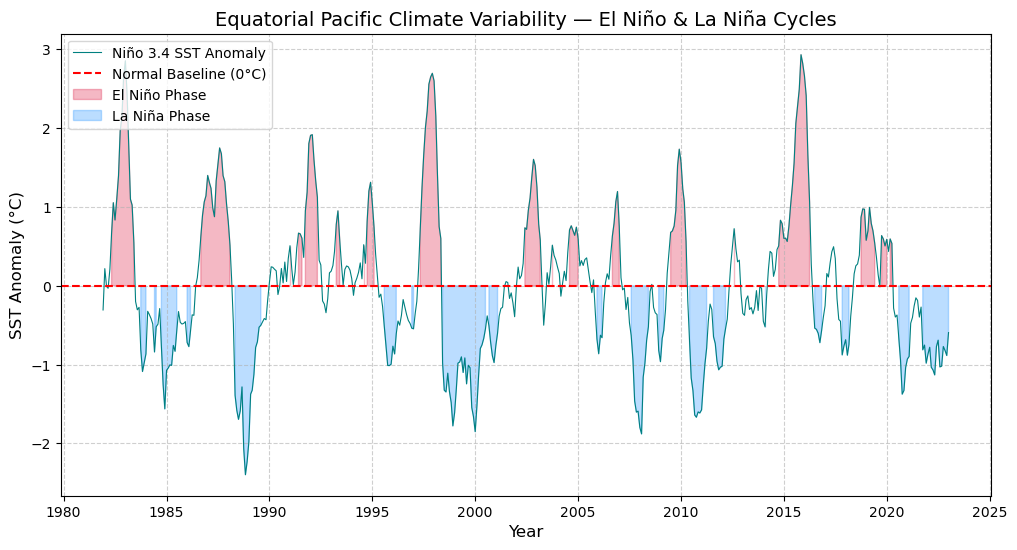

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# 1. Connect to NOAA's OISST dataset via OPeNDAP
url = "https://psl.noaa.gov/thredds/dodsC/Datasets/noaa.oisst.v2/sst.mnmean.nc"
print("Connecting to NOAA climate server...")
ds = xr.open_dataset(url).sortby('lat')

# 2. Extract the Niño 3.4 region (5°S to 5°N, 190°E to 240°E)
print("Extracting equatorial Pacific region...")
niño34 = ds.sst.sel(lat=slice(-5, 5), lon=slice(190, 240))

# 3. Compute cosine-weighted spatial mean
print("Calculating weighted spatial average...")
weights = np.cos(np.deg2rad(niño34.lat))
niño34_mean = niño34.weighted(weights).mean(dim=['lat', 'lon'], skipna=True).load()

# 4. Compute monthly anomaly by subtracting month-by-month climatology
# (Optional: use .sel(time=slice('1991', '2020')) inside mean() for standard 30-yr baseline)
climatology = niño34_mean.groupby('time.month').mean('time')
niño34_anomaly = niño34_mean.groupby('time.month') - climatology

print("Data processed successfully! Plotting climate anomaly time-series...")

# 5. Plot the multi-decadal temperature anomaly variability
plt.figure(figsize=(12, 6))
plt.plot(niño34_anomaly.time, niño34_anomaly, color='teal', linewidth=0.8, label='Niño 3.4 SST Anomaly')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Normal Baseline (0°C)')

# Shade El Niño (>= +0.5°C) and La Niña (<= -0.5°C) phases
plt.fill_between(
    niño34_anomaly.time, 
    niño34_anomaly, 
    0, 
    where=(niño34_anomaly >= 0.5), 
    color='crimson', 
    alpha=0.3, 
    label='El Niño Phase'
)
plt.fill_between(
    niño34_anomaly.time, 
    niño34_anomaly, 
    0, 
    where=(niño34_anomaly <= -0.5), 
    color='dodgerblue', 
    alpha=0.3, 
    label='La Niña Phase'
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("SST Anomaly (°C)", fontsize=12)
plt.title("Equatorial Pacific Climate Variability — El Niño & La Niña Cycles", fontsize=14)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)

# 6. Save the output figure
plt.savefig("../figures/climate_variability_timeseries.png", dpi=300, bbox_inches='tight')
plt.show()